<a href="https://colab.research.google.com/github/ayaaqais/Resampling-Datetime-Data/blob/main/london_weather_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Project: London Weather

**Author:** Aya Khalil

## Goal

In this project I work with **London weather data** as a **time series**. The two parts are:

**Part 1 - Load the data and make a datetime index**
- Read the CSV.
- Turn the `date` column into a real datetime and use it as the index.
- Keep only data from the year **2000** onward, and only the columns we need.
- Fill in missing values, choosing a sensible method **for each feature**.

**Part 2 - Answer two questions with the correct frequency**
- **Q1:** Which month had the most precipitation between 2000 and 2010?
- **Q2:** Which year between 2000 and 2020 had the coolest average temperature?

For each question I resample the data to the right frequency, then make a clear plot with properly formatted date ticks.

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tools for nicely formatting date ticks on the x-axis.
import matplotlib.dates as mdates

%matplotlib inline

# Part 1 - Load the Data and Make a Datetime Index

## 2. Load the Data

We read the London weather CSV.

> If you are loading from the Google Sheets link in the assignment instead of a local file, replace the line below with:
> ```python
> url = "PASTE_YOUR_GOOGLE_SHEETS_EXPORT_CSV_LINK_HERE"
> df = pd.read_csv(url)
> ```

In [ ]:
# Read the data from the local CSV file.
df = pd.read_csv("london_weather_MODIFIED - london_weather_MODIFIED.csv")

print("Shape:", df.shape)
df.head()

Shape: (15341, 10)


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


## 3. Convert `date` to Datetime and Set It as the Index

Right now the `date` column is just a number like `19790101`. We tell pandas its format is **YYYYMMDD** so it becomes a real date. Then we set it as the **index**, which is what makes this a proper time series.

In [ ]:
# Turn the YYYYMMDD number into a real datetime.
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

# Use the date as the index of the DataFrame.
df = df.set_index("date")

print("Index type:", type(df.index))
df.head()

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
date,,,,,,,,,
1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


## 4. Filter the Data

The assignment asks us to:
- keep only rows from the year **2000 or later**, and
- keep only these columns: `precipitation`, `mean_temp`, `max_temp`, `min_temp`, `snow_depth`.

In [ ]:
# Keep only the years 2000 and later.
df = df[df.index.year >= 2000]

# Keep only the columns we need.
columns_to_keep = ["precipitation", "mean_temp", "max_temp", "min_temp", "snow_depth"]
df = df[columns_to_keep]

print("Shape after filtering:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
df.head()

Shape after filtering: (7671, 5)
Date range: 2000-01-01 to 2020-12-31


,precipitation,mean_temp,max_temp,min_temp,snow_depth
date,,,,,
2000-01-01,0.0,7.0,10.8,4.9,0.0
2000-01-02,0.2,7.9,11.5,5.0,0.0
2000-01-03,6.0,9.4,9.5,7.2,0.0
2000-01-04,0.2,7.0,11.0,4.4,0.0
2000-01-05,0.8,6.4,10.8,1.9,0.0


## 5. Handle Missing Values (One Method per Feature)

Let's see how many values are missing in each column.

In [ ]:
df.isnull().sum()

,0
precipitation,390
mean_temp,419
max_temp,390
min_temp,386
snow_depth,1752


### Choosing a method for each feature

Different features need different fixes:

- **`mean_temp`, `max_temp`, `min_temp`** -> **interpolate**. Temperature changes smoothly from day to day, so filling a gap with a value *between* the days before and after it is the most realistic choice.
- **`precipitation`** -> **fill with 0**. A missing rainfall reading is most safely treated as "no rain recorded" (precipitation can never be negative, and most days are dry).
- **`snow_depth`** -> **fill with 0**. London has snow only rarely, so a missing snow value almost always means there was no snow.

So we use **interpolation** for the temperatures and **fill-with-0** for precipitation and snow depth.

In [ ]:
# Temperatures: fill gaps by interpolating between neighbouring days.
for col in ["mean_temp", "max_temp", "min_temp"]:
    df[col] = df[col].interpolate()

# Precipitation and snow depth: a missing value means "none", so fill with 0.
df["precipitation"] = df["precipitation"].fillna(0)
df["snow_depth"]    = df["snow_depth"].fillna(0)

# Check that there are no missing values left.
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


# Part 2 - Answer the Questions

For each question we make a **copy of the data resampled to the correct frequency**, then plot it.

> **Note on frequency codes:** `"ME"` means *month end* and `"YE"` means *year end*. (Older versions of pandas use `"M"` and `"Y"`.)

## Q1 - Which month had the most precipitation between 2000 and 2010?

**Plan:**
- Take the `precipitation` column for 2000-2010.
- Resample it to a **monthly** frequency and **sum** the rain in each month (total rainfall per month).
- Find the month with the highest total.

In [ ]:
# Take precipitation for 2000-2010 and total it up for each month.
precip_monthly = df["precipitation"].loc["2000":"2010"].resample("ME").sum()

# Find the wettest month and its value.
wettest_month = precip_monthly.idxmax()
wettest_value = precip_monthly.max()

print("Wettest month:", wettest_month.strftime("%B %Y"))
print("Total precipitation:", round(wettest_value, 1), "mm")

Wettest month: November 2009
Total precipitation: 138.4 mm


## Q1 - Plot

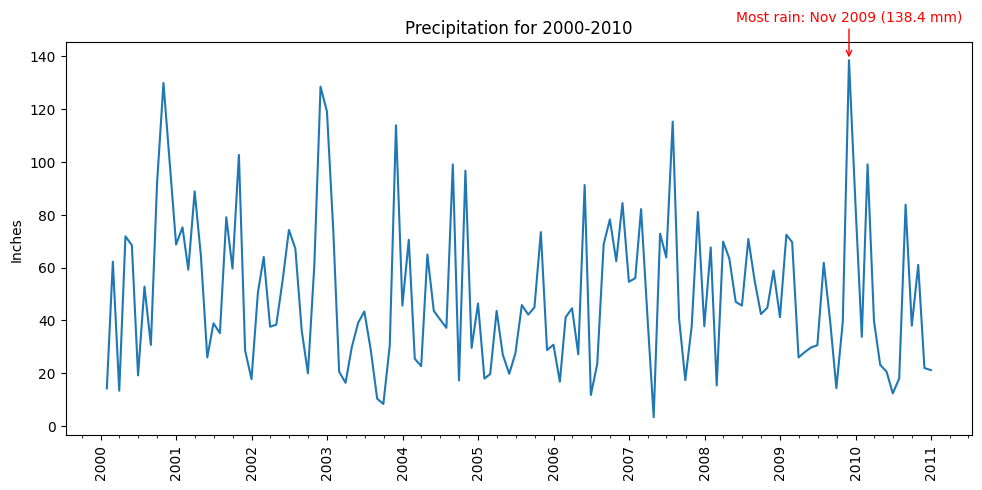

In [ ]:
# Use the fig, ax pattern (the assignment's recommended workaround).
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the monthly precipitation over time.
ax.plot(precip_monthly.index, precip_monthly.values)

# Title and y-axis label (as required by the assignment).
ax.set_title("Precipitation for 2000-2010")
ax.set_ylabel("Inches")

# Major ticks: one per YEAR, shown as a 4-digit year, rotated 90 degrees.
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Minor ticks: every 3 months, with NO labels (default).
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

# Rotate the year labels so they do not overlap.
plt.setp(ax.get_xticklabels(), rotation=90)

# Mark the wettest month on the plot.
ax.annotate(
    f"Most rain: {wettest_month.strftime('%b %Y')} ({wettest_value:.1f} mm)",
    xy=(wettest_month, wettest_value),
    xytext=(wettest_month, wettest_value + 15),
    ha="center", color="red",
    arrowprops=dict(arrowstyle="->", color="red")
)

fig.tight_layout()
plt.show()

### Q1 Answer

The month with the most precipitation between 2000 and 2010 was **November 2009**, with about **138.4 mm** of rain — the tallest peak on the chart.

## Q2 - Which year between 2000 and 2020 had the coolest average temperature?

**Plan:**
- Take the `mean_temp` column for 2000-2020.
- Resample it to a **yearly** frequency and take the **average** (mean) temperature for each year.
- Find the year with the lowest average.

In [ ]:
# Take mean_temp for 2000-2020 and average it for each year.
temp_yearly = df["mean_temp"].loc["2000":"2020"].resample("YE").mean()

# Find the coolest year and its value.
coolest_year  = temp_yearly.idxmin()
coolest_value = temp_yearly.min()

print("Coolest year:", coolest_year.year)
print("Average temperature:", round(coolest_value, 2), "degrees C")

Coolest year: 2010
Average temperature: 10.66 degrees C


## Q2 - Plot

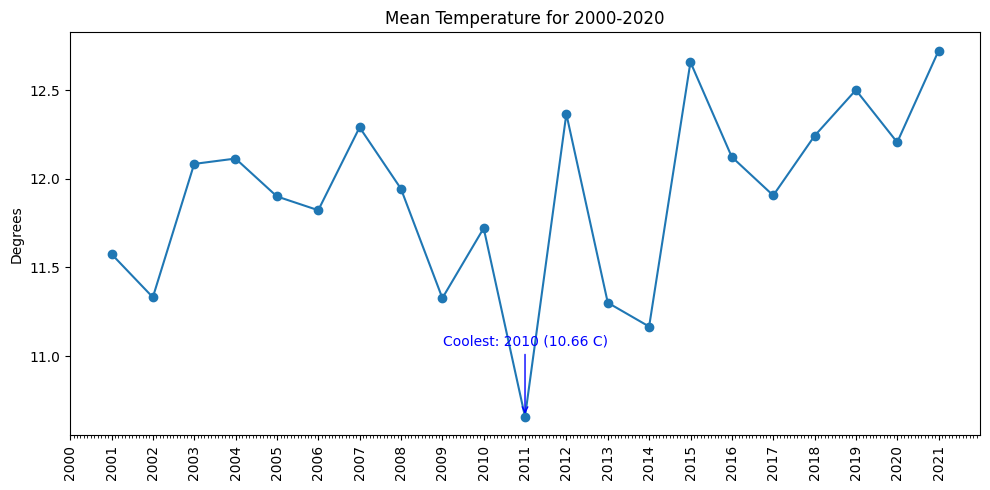

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the yearly average temperature (markers help since there is one point per year).
ax.plot(temp_yearly.index, temp_yearly.values, marker="o")

ax.set_title("Mean Temperature for 2000-2020")
ax.set_ylabel("Degrees")

# Major ticks: one per YEAR, 4-digit year, rotated 90 degrees.
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Minor ticks: every 1 month, with NO labels.
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=90)

# Mark the coolest year on the plot.
ax.annotate(
    f"Coolest: {coolest_year.year} ({coolest_value:.2f} C)",
    xy=(coolest_year, coolest_value),
    xytext=(coolest_year, coolest_value + 0.4),
    ha="center", color="blue",
    arrowprops=dict(arrowstyle="->", color="blue")
)

fig.tight_layout()
plt.show()

### Q2 Answer

The coolest year between 2000 and 2020 was **2010**, with an average temperature of about **10.66 degrees C** — the lowest point on the chart.

## Summary

In this time series project I:

- Loaded the London weather data and turned the `date` column into a **datetime index**.
- Filtered to the years **2000+** and kept only the 5 needed columns.
- Filled missing values with a method chosen **per feature**: **interpolation** for the temperatures (they change smoothly) and **fill-with-0** for precipitation and snow depth (missing usually means "none").
- Answered the two questions by **resampling to the correct frequency**:
  - **Q1:** Resampled precipitation to **monthly totals** -> the wettest month in 2000-2010 was **November 2009** (~138.4 mm).
  - **Q2:** Resampled mean temperature to **yearly averages** -> the coolest year in 2000-2020 was **2010** (~10.66 C).
- Made clear plots with **yearly major ticks** (4-digit, rotated) and **unlabeled minor ticks**, and marked the answer on each chart.